# Deep RNNs | Stacked RNNs | Stacked LSTMs | Stacked GRUs

## Importing Libraries

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import matplotlib.pyplot as plt

## Loading the Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=5000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Padding the Sequences

In [3]:
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=100)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=100)

In [4]:
X_train.shape

(25000, 100)

In [5]:
X_test.shape

(25000, 100)

In [6]:
len(X_train[0])

100

## Deep RNN

In [7]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.SimpleRNN(units=5, return_sequences=True),
        keras.layers.SimpleRNN(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,251 (625.98 KB)

 Trainable params: 160,251 (625.98 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [10]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.6127 - loss: 0.6464 - val_accuracy: 0.7600 - val_loss: 0.5152
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8242 - loss: 0.4171 - val_accuracy: 0.8148 - val_loss: 0.4201
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8907 - loss: 0.2873 - val_accuracy: 0.8166 - val_loss: 0.4258
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9270 - loss: 0.2160 - val_accuracy: 0.8202 - val_loss: 0.4660
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9419 - loss: 0.1769 - val_accuracy: 0.8133 - val_loss: 0.5179
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9449 - loss: 0.1602 - val_accuracy: 0.8040 - val_loss: 0.5576
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9663 - loss: 0.1134 - val_accuracy: 0.8049 - val_loss: 0.5917
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9711 - loss: 0.1004 - val_acc

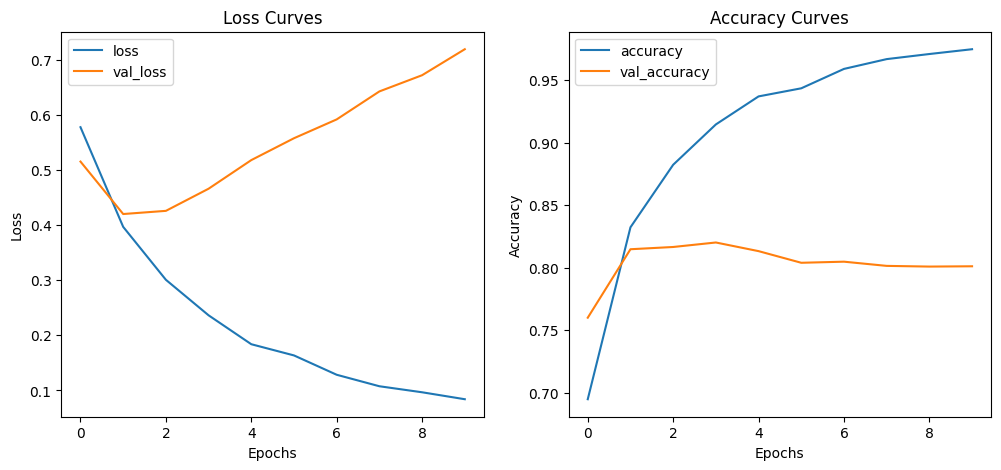

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## LSTM

In [12]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.LSTM(units=5, return_sequences=True),
        keras.layers.LSTM(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 5)         │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5)              │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,986 (628.85 KB)

 Trainable params: 160,986 (628.85 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [15]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6778 - loss: 0.5914 - val_accuracy: 0.8372 - val_loss: 0.3867
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8761 - loss: 0.3210 - val_accuracy: 0.8450 - val_loss: 0.3636
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9013 - loss: 0.2621 - val_accuracy: 0.8376 - val_loss: 0.3995
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9271 - loss: 0.2098 - val_accuracy: 0.8364 - val_loss: 0.4209
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9390 - loss: 0.1799 - val_accuracy: 0.8268 - val_loss: 0.4178
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9498 - loss: 0.1546 - val_accuracy: 0.8305 - val_loss: 0.4558
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9598 - loss: 0.1316 - val_accuracy: 0.8319 - val_loss: 0.4733
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9669 - loss: 0.1146 - val_ac

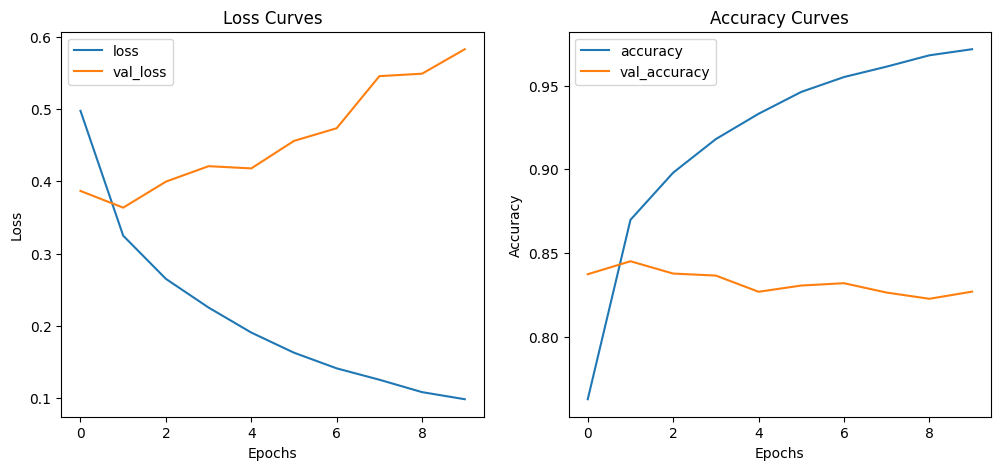

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## GRU

In [17]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.GRU(units=5, return_sequences=True),
        keras.layers.GRU(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 5)         │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,771 (628.01 KB)

 Trainable params: 160,771 (628.01 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [20]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6567 - loss: 0.6020 - val_accuracy: 0.8364 - val_loss: 0.3791
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8634 - loss: 0.3326 - val_accuracy: 0.8455 - val_loss: 0.3563
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9004 - loss: 0.2660 - val_accuracy: 0.8481 - val_loss: 0.3531
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9131 - loss: 0.2288 - val_accuracy: 0.8486 - val_loss: 0.3607
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9276 - loss: 0.2077 - val_accuracy: 0.8440 - val_loss: 0.3828
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9410 - loss: 0.1728 - val_accuracy: 0.8436 - val_loss: 0.3897
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9496 - loss: 0.1526 - val_accuracy: 0.8348 - val_loss: 0.4602
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9593 - loss: 0.1311 - val_acc

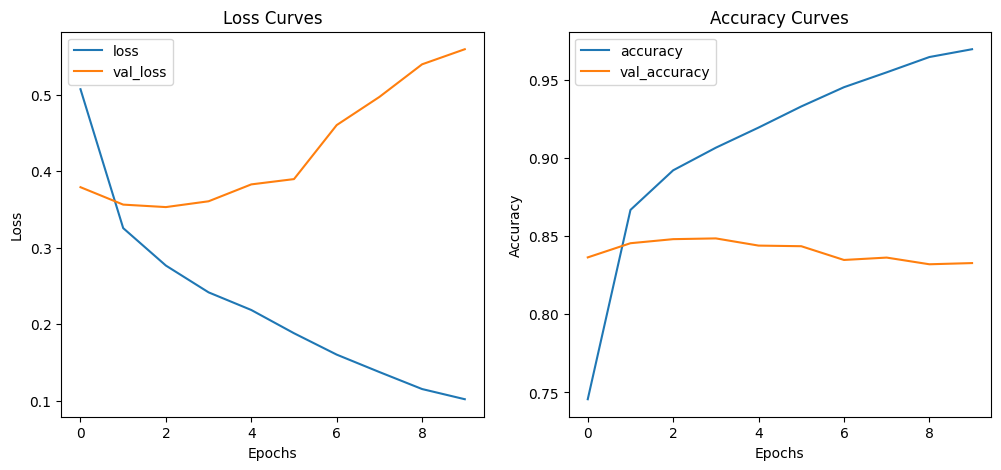

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Differences of Training and Validation Accuracy Between RNN, LSTM, and GRU

---


* **RNN:** 97.85% − 80.12% = **17.73%**
* **LSTM:** 97.58% − 82.68% = **14.90%**
* **GRU:** 97.44% − 83.28% = **14.16%**

## Bidirectional RNN

In [22]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.Bidirectional(
            keras.layers.SimpleRNN(units=5, return_sequences=True)
        ),
        keras.layers.Bidirectional(keras.layers.SimpleRNN(units=5)),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [23]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 10)        │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,551 (627.15 KB)

 Trainable params: 160,551 (627.15 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [25]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.6590 - loss: 0.6218 - val_accuracy: 0.7998 - val_loss: 0.4601
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.8199 - loss: 0.4205 - val_accuracy: 0.7200 - val_loss: 0.5577
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.8372 - loss: 0.3884 - val_accuracy: 0.8161 - val_loss: 0.4198
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9142 - loss: 0.2334 - val_accuracy: 0.8153 - val_loss: 0.4366
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9464 - loss: 0.1593 - val_accuracy: 0.8108 - val_loss: 0.4899
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9684 - loss: 0.1066 - val_accuracy: 0.8129 - val_loss: 0.5263
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9809 - loss: 0.0721 - val_accuracy: 0.8136 - val_loss: 0.6188
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9796 - loss: 0.0676 - 

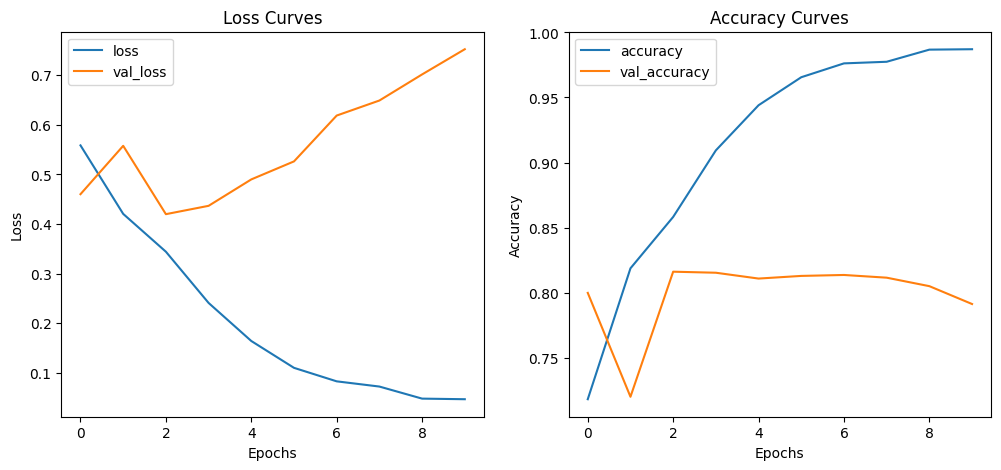

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Bidirectional LSTM

In [27]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.Bidirectional(
            keras.layers.LSTM(units=5, return_sequences=True)
        ),
        keras.layers.Bidirectional(keras.layers.LSTM(units=5)),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [28]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 10)        │         1,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 10)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,171 (633.48 KB)

 Trainable params: 162,171 (633.48 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [30]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.7059 - loss: 0.5654 - val_accuracy: 0.8282 - val_loss: 0.4000
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8536 - loss: 0.3557 - val_accuracy: 0.8427 - val_loss: 0.3681
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8906 - loss: 0.2851 - val_accuracy: 0.8504 - val_loss: 0.3556
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9055 - loss: 0.2495 - val_accuracy: 0.8478 - val_loss: 0.3644
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9155 - loss: 0.2278 - val_accuracy: 0.8506 - val_loss: 0.3742
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9260 - loss: 0.2038 - val_accuracy: 0.8455 - val_loss: 0.3920
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9417 - loss: 0.1755 - val_accuracy: 0.8435 - val_loss: 0.4006
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9458 - loss: 0.1570 - 

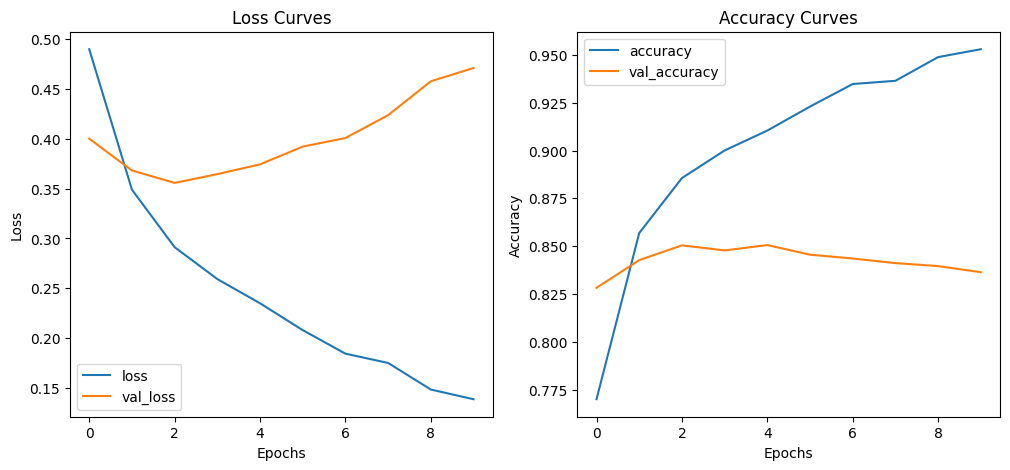

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Bidirectional GRU

In [32]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.Bidirectional(
            keras.layers.GRU(units=5, return_sequences=True)
        ),
        keras.layers.Bidirectional(keras.layers.GRU(units=5)),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [33]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 10)        │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,691 (631.61 KB)

 Trainable params: 161,691 (631.61 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [35]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test,y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6555 - loss: 0.6121 - val_accuracy: 0.8366 - val_loss: 0.3837
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8706 - loss: 0.3268 - val_accuracy: 0.8456 - val_loss: 0.3631
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8950 - loss: 0.2738 - val_accuracy: 0.8482 - val_loss: 0.3538
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9161 - loss: 0.2285 - val_accuracy: 0.8470 - val_loss: 0.3689
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9317 - loss: 0.1914 - val_accuracy: 0.8444 - val_loss: 0.3916
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9416 - loss: 0.1729 - val_accuracy: 0.8355 - val_loss: 0.4437
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9517 - loss: 0.1444 - val_accuracy: 0.8329 - val_loss: 0.4649
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9613 - loss: 0.1202 - val_

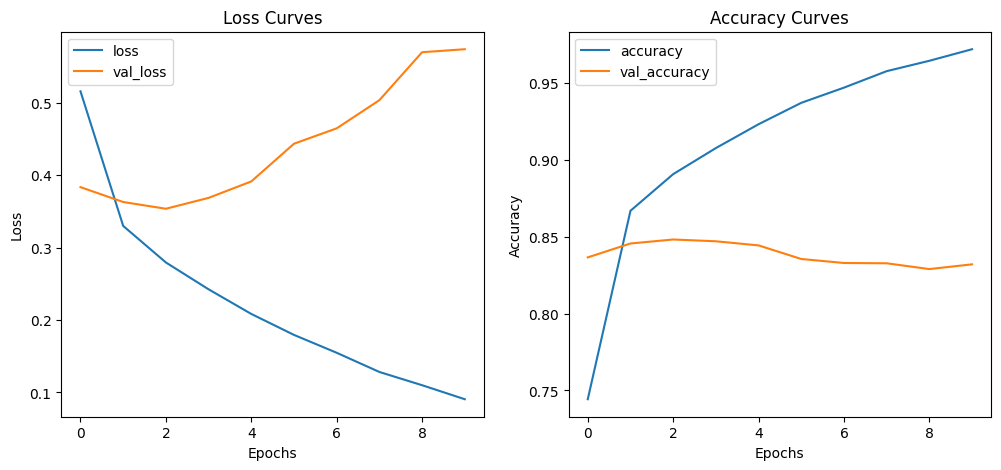

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Differences of Training and Validation Accuracy Between BiRNN, BiLSTM, and BiGRU

---


* **BiRNN:** 98.96% − 79.13% = **19.83%**
* **BiLSTM:** 95.97% − 83.64% = **12.33%**
* **BiGRU:** 97.30% − 83.20% = **14.10%**